<a href="https://colab.research.google.com/github/yasaswitaraja/SentinelNet/blob/main/notebooks/CICIDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX (2).csv


In [ ]:
#Load dataset
df = pd.read_csv('/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

print("Shape:", df.shape)
print(df.head())


Shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                           

In [ ]:

drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=drop_cols, errors='ignore')

df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

print("After cleaning:", df.shape)


After cleaning: (225745, 79)


In [ ]:
#Label Encoding
df['attack_binary'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print(df['attack_binary'].value_counts())

attack_binary
1    128027
0     97718
Name: count, dtype: int64


/tmp/ipython-input-2594658914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=df, palette='Set2')


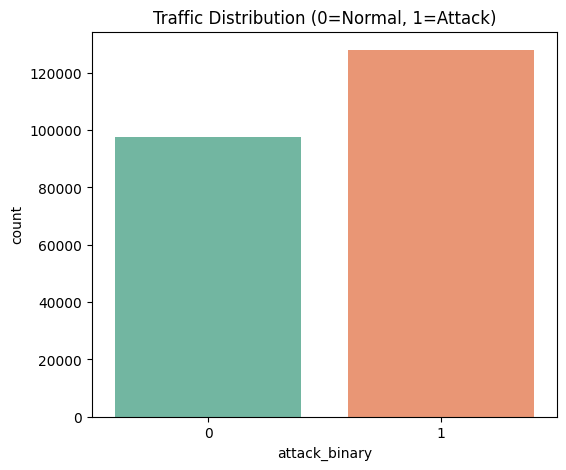

/tmp/ipython-input-2594658914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=' Label', data=attack_df, order=attack_df[' Label'].value_counts().index, palette='viridis')


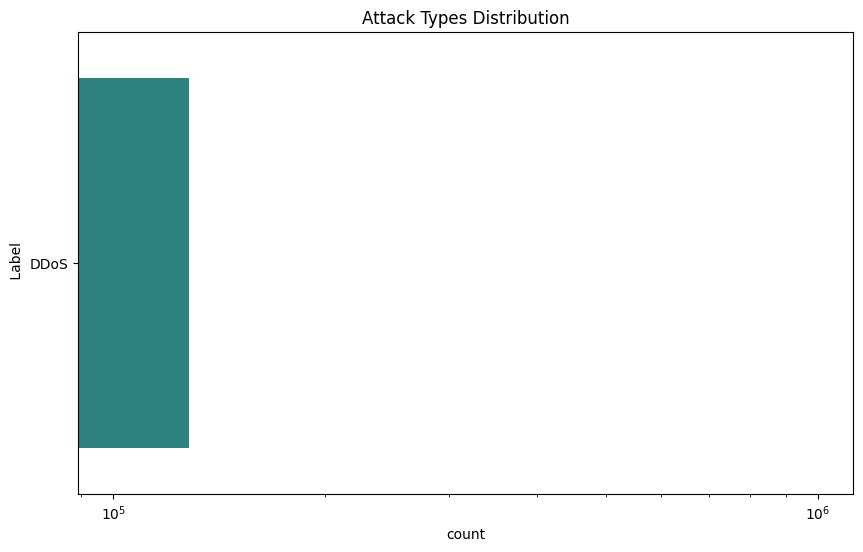

In [ ]:
#Distributions
plt.figure(figsize=(6,5))
sns.countplot(x='attack_binary', data=df, palette='Set2')
plt.title("Traffic Distribution (0=Normal, 1=Attack)")
plt.show()

attack_df = df[df['attack_binary'] == 1]
plt.figure(figsize=(10,6))
sns.countplot(y=' Label', data=attack_df, order=attack_df[' Label'].value_counts().index, palette='viridis')
plt.title("Attack Types Distribution")
plt.xscale('log')
plt.show()

In [ ]:
#Split features/target
X = df.drop([' Label', 'attack_binary'], axis=1)
y = df['attack_binary']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

print("Categorical:", categorical_cols)
print("Numerical count:", len(numerical_cols))

Categorical: Index([], dtype='object')
Numerical count: 78


In [ ]:
#One-Hot Encode categorical
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X.shape)


Shape after encoding: (225745, 78)


In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (180596, 78) (180596,)
Test shape: (45149, 78) (45149,)


In [ ]:
#Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaled training data head:")
print(X_train.head())


Scaled training data head:
         Destination Port   Flow Duration   Total Fwd Packets  \
207214          -0.446783       -0.512402           -0.245274   
92421           -0.445417       -0.460875           -0.118648   
116240          -0.445417       -0.486197           -0.118648   
126095          -0.445417       -0.512541           -0.118648   
85923           -0.445417       -0.464501           -0.118648   

         Total Backward Packets  Total Length of Fwd Packets  \
207214                -0.160493                    -0.279247   
92421                  0.019328                    -0.283602   
116240                 0.019328                    -0.283602   
126095                 0.064283                    -0.283602   
85923                  0.019328                    -0.283602   

         Total Length of Bwd Packets   Fwd Packet Length Max  \
207214                     -0.145444               -0.267527   
92421                       0.139396               -0.278271   
11624

In [ ]:
#Handle imbalance (SMOTE)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Original:", y_train.value_counts())
print("Resampled:", y_train_res.value_counts())


Original: attack_binary
1    102422
0     78174
Name: count, dtype: int64
Resampled: attack_binary
0    102422
1    102422
Name: count, dtype: int64


In [ ]:
#Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))
    print("="*50)


Training Logistic Regression...
Logistic Regression Accuracy: 99.89%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19544
      Attack       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Training Decision Tree...
Decision Tree Accuracy: 100.00%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19544
      Attack       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Training Random Forest...
Random Forest Accuracy: 99.99%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19544
      Attack       1.00      1.00      1.00     25605

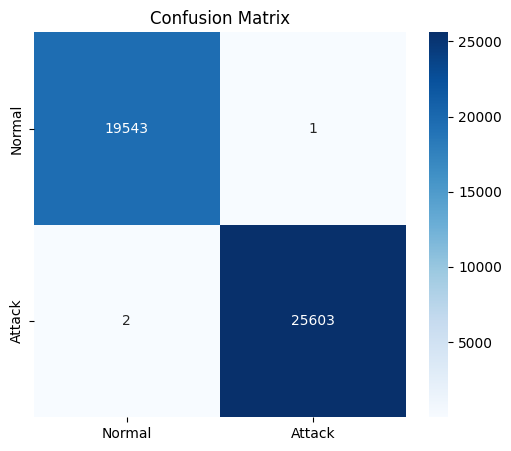

In [ ]:
#Confusion Matrix
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train_res, y_train_res)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
plt.title("Confusion Matrix")
plt.show()
